## Spatial Structure Investigation: Receptive Field Analysis

Analysis Workflow:
- Receptive Field Estimation: Estimate receptive fields for all neurons using the spike-triggered average (STA) method.

- Feature Extraction: Quantify key RF properties.

- Dimensionality Reduction: Apply Gaussian smoothing and normalization to RFs, then use PCA and t-SNE for low-dimensional visualization.

- Clustering Analysis: Identify functional neuron groups using K-means and Gaussian Mixture Models (GMM) on t-SNE embeddings.

- Clustering Evaluation: 
    - Statistical: silhouette and Davies-Bouldin scores. 
    - Biological: Assess clusters for spatial coherence, distinctiveness, cortical organization, and RF symmetry consistency.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from rfest.utils import build_design_matrix
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

In [2]:
# load data
def load_data(path="."):
    def array2df(d, key, cols):
        d[key] = pd.DataFrame(d[key], columns=cols)

    data = np.load(path + "/dff_data_rf.npz", allow_pickle=True)
    data = dict(data)
    array2df(data, "stim_table", ["frame", "start", "end"])
    array2df(data, "stim_epoch_table", ["start", "end", "stimulus"])

    return data


def print_info(data):
    data_iter = ((k, type(v), v.shape) for k, v in data.items())
    l = [f"[{k}] - {t}, - {s}" for k, t, s in data_iter]
    print("\n".join(l) + "\n")


path = os.getcwd()
data = load_data(path)

print("Overview of the data")
print_info(data)

Overview of the data
[t] - <class 'numpy.ndarray'>, - (105968,)
[dff] - <class 'numpy.ndarray'>, - (189, 105968)
[stim_table] - <class 'pandas.core.frame.DataFrame'>, - (8880, 3)
[stim] - <class 'numpy.ndarray'>, - (9000, 16, 28)
[roi_masks] - <class 'numpy.ndarray'>, - (189, 512, 512)
[max_projection] - <class 'numpy.ndarray'>, - (512, 512)
[running_speed] - <class 'numpy.ndarray'>, - (2, 105968)
[stim_epoch_table] - <class 'pandas.core.frame.DataFrame'>, - (7, 3)



In [3]:
# Stimuli
stim_epochs = data["stim_epoch_table"]
stim_epochs.columns = ["stimulus", "start", "end"]
stim_metadata = data["stim_table"]
stims = data["stim"]

# Roi masks and projections
roi_masks = data["roi_masks"]
max_projection = data["max_projection"]

# time
time = data["t"]
dt = np.median(np.diff(time))  # sampling interval in seconds
fs = 1 / dt  # sampling frequency in Hz
Dx, Dy = stims.shape[1:]

In [4]:
def build_stimulus_matrix(stims, stim_epochs, stim_metadata, trace_length):
    """
    Builds stimulus matrix `s` of shape (Dx * Dy, nT), where each column is the stimulus
    shown at that timepoint, or zeros if no stimulus was shown.

    Parameters:
        stims: np.array of shape (9000, Dx, Dy)
        stim_epochs: pd.DataFrame with 'stimulus', 'start', 'end'
        stim_metadata: pd.DataFrame with 'frame', 'start', 'end'
        trace_length: int, number of timepoints in spike train

    Returns:
        s: np.array of shape (Dx*Dy, nT)
    """

    Dx, Dy = stims.shape[1], stims.shape[2]
    nT = trace_length
    s = np.zeros((nT, Dx, Dy), dtype=stims.dtype)

    # Filter epochs for locally sparse noise
    lsn_epochs = stim_epochs[stim_epochs["stimulus"] == "locally_sparse_noise"]

    # Flatten each stim frame once
    flat_stims = stims.reshape(stims.shape[0], -1)  # shape (9000, Dx*Dy)

    # Loop through all metadata rows and check if the frame belongs to LSN
    for _, row in stim_metadata.iterrows():
        frame = row["frame"]
        t_start = int(row["start"])
        t_end = int(row["end"])

        # Check if this frame falls within any LSN epoch
        in_lsn = any(
            (t_start >= epoch_start) and (t_end <= epoch_end)
            for epoch_start, epoch_end in zip(lsn_epochs["start"], lsn_epochs["end"])
        )
        if in_lsn and frame < len(flat_stims):
            # Fill in the same stimulus vector across the time window
            s[t_start:t_end, :] = stims[frame]
            # [:, np.newaxis]
    s = s.reshape(nT, Dx, Dy)
    return s

We load OASIS spikes and construct the stimulus matrix

In [5]:
oasis_result = np.load("OASIS_spikes.npz")
oasis_spikes = oasis_result["spike_likelihoods"]

In [6]:
trace_length = len(oasis_spikes[0, :])
stims_valid = build_stimulus_matrix(stims, stim_epochs, stim_metadata, trace_length)

This section contains commented code for computing receptive fields using Spike-Triggered Average.

For Each Neuron we:
- Build design matrix from stimulus
- fit RF model (STA or splineLNP)
- compute RF center in visual space
- Compute cortical position from ROI mask
- Store results for further analysis

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.ndimage import center_of_mass
# from tqdm import tqdm

# n_neurons = roi_masks.shape[0]
# neuron_ids = np.arange(n_neurons)

# n_neurons = oasis_spikes.shape[0]
# rf_results = []

# # # Loop over all neuron IDs
# for neuron_id in tqdm(neuron_ids):
#     try:
#         # 1. Build design matrix
#         X = build_design_matrix(stims_valid.reshape((stims_valid.shape[0], -1)), 1)
#         y = oasis_spikes[neuron_id]

#         # 2. Fit STA model
#         w_sta= X.T@y
#         w_sta = w_sta.reshape(Dx,Dy)
#         # 4. Compute RF center (in visual space)
#         rf_center = center_of_mass(np.abs(w_sta))  # (y, x)

#         # 5. Compute cortical position from ROI mask
#         roi_mask = roi_masks[neuron_id]
#         cortical_pos = center_of_mass(roi_mask)  # (y, x)

#         # 6. Store result
#         rf_results.append(
#             {
#                 "neuron_id": neuron_id,
#                 "rf_map": w_sta,
#                 "rf_center": rf_center,
#                 "cortical_position": cortical_pos,
#             }
#         )

#     except Exception as e:
#         print(f"Error for neuron {neuron_id}: {e}")
#         continue

Load previously computed receptive field results from saved files:

### Receptive Field Characterization

**1. RF Peak Amplitude**:  Measures maximum response strength

**2. RF Symmetry**: Assesses spatial organization and orientation preference

**3. Inter-neuronal Similarity**: Quantifies functional relationships between neurons. Pairwise Pearson correlations between flattened RFs

In [8]:
def compute_rf_peak(rf_map):
    """
    Maximum absolute value in the RF.
    """
    rf_map = np.asarray(rf_map, dtype=float)
    return float(np.max(np.abs(rf_map)))

In [9]:

def rf_symmetry(rf_map, axis=1):
    """
    Correlate RF with its mirror-image along given axis.
    axis=1 for left-right; axis=0 for up-down.
    Returns np.nan if RF is constant.
    """
    rf_map = np.asarray(rf_map, dtype=float)
    max_abs = np.max(np.abs(rf_map))
    if max_abs == 0:
        return np.nan
    rf_norm = rf_map / max_abs
    rf_flip = np.flip(rf_norm, axis=axis)
    a = rf_norm.ravel()
    b = rf_flip.ravel()
    if np.allclose(a.std(), 0) or np.allclose(b.std(), 0):
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


In [10]:
def compute_rf_similarity_matrix(rf_maps):
    """
    Pairwise Pearson correlation between flattened RFs.
    """
    rf_maps = np.asarray(rf_maps, dtype=float)
    N = rf_maps.shape[0]
    flat = rf_maps.reshape(N, -1)
    # Guard against zero-variance rows
    stds = flat.std(axis=1, keepdims=True)
    stds[stds == 0] = 1.0
    flat_z = (flat - flat.mean(axis=1, keepdims=True)) / stds
    # Corr = Z Z^T / (n-1)
    # Use np.corrcoef for clarity (N small)
    sim = np.corrcoef(flat_z)
    return sim

In [11]:
# =========================
# Compute Metrics for All RFs
# =========================

def compute_all_rf_metrics(rf_maps):
    rf_maps = np.asarray(rf_maps)
    N = rf_maps.shape[0]
    
    sizes = np.empty(N, dtype=float)
    peaks = np.empty(N, dtype=float)
    symms = np.empty(N, dtype=float)
    freqs = np.empty(N, dtype=float)
    
    for i in range(N):
        rf = rf_maps[i]

        peaks[i] = compute_rf_peak(rf)
        symms[i] = rf_symmetry(rf, axis=1)

    sim_matrix = compute_rf_similarity_matrix(rf_maps)
    # Per-neuron mean similarity to others (exclude self)
    N = len(sim_matrix)
    mean_sim = (sim_matrix.sum(axis=1) - 1.0) / (N - 1)
    # Upper triangle (pairwise similarities)
    iu = np.triu_indices(N, k=1)
    pairwise_sims = sim_matrix[iu]
    
    metrics = dict(
        sizes=sizes,
        peaks=peaks,
        symmetries=symms,
        freq_radius=freqs,
        mean_similarity=mean_sim,
        pairwise_similarity=pairwise_sims,
        sim_matrix=sim_matrix,
    )
    return metrics

In [12]:
def plot_rf_metrics_histograms(metrics, bins=30, figsize=(15,4)):
    """
    metrics: dict from compute_all_rf_metrics
    Creates a multi-panel figure with histograms.
    """

    peaks = metrics['peaks']
    symms = metrics['symmetries']
    mean_sim = metrics['mean_similarity']
    pair_sims = metrics['pairwise_similarity']
    
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    axes = axes.ravel()

    # RF peaks
    axes[0].hist(peaks, bins=bins, color='0.5')
    axes[0].set_title('RF peak amplitude')
    axes[0].set_xlabel('Amplitude')

    # RF symmetry
    axes[1].hist(symms[~np.isnan(symms)], bins=bins, color='0.5')
    axes[1].set_title('RF symmetry (corr w/ flip)')
    axes[1].set_xlabel('Correlation')

    # Mean similarity per neuron
    axes[2].hist(mean_sim, bins=bins, color='0.5')
    axes[2].set_title('Mean RF similarity (per neuron)')
    axes[2].set_xlabel('Mean corr to others')

    # Pairwise similarities
    axes[3].hist(pair_sims, bins=bins, color='0.5')
    axes[3].set_title('All pairwise RF similarities')
    axes[3].set_xlabel('Correlation')

    plt.tight_layout()
    plt.show()


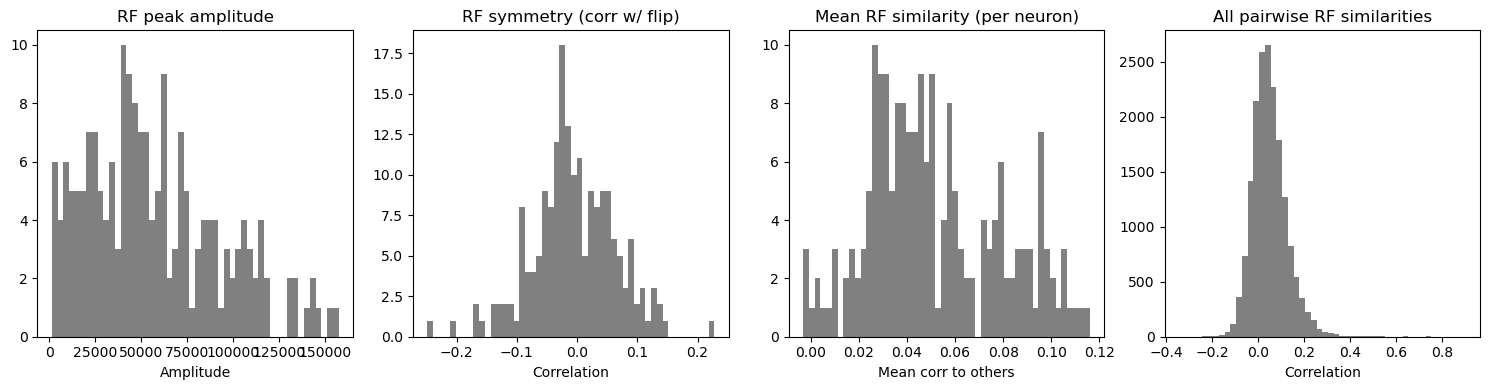

In [13]:
rf_results_STA= np.load("STA_rfs.npy", allow_pickle=True)
rf_maps =np.array([d["rf_map"] for d in rf_results_STA])
metrics = compute_all_rf_metrics(rf_maps)
plot_rf_metrics_histograms(metrics, bins=50)

1. **RF Peak Distribution:**
    - Observation: Wide range of peak amplitudes (30,000-70,000 units)
    - Interpretation: Diverse response strengths across neurons
    - Biological implication: Different neurons may have varying sensitivity or signal-to-noise ratios

2. **RF Symmetry Distribution:**
    - Observation: Symmetry scores cluster around zero with some spread
    - Interpretation: Most RFs show asymmetry
    - Biological implication: Neurons may have subtle orientation or directional preferences

3. **Similarity Distributions:**
    - Observation: Mean similarities around 0.1-0.2, pairwise similarities show clustering structure
    - Interpretation: Moderate functional diversity with some grouping
    - Biological implication: Neurons form functional clusters.

### Dimensionality Reduction 

We first apply Gaussian smoothing and normalization to the RFs to enhance signal quality and comparability across neurons.
 
Principal Component Analysis (PCA) is then used to reduce the dimensionality of the RF data, capturing the main sources of variation. The PCA output serves as the initialization for t-SNE, which provides a two-dimensional embedding suitable for visualization and subsequent clustering analysis. This approach ensures that clustering is performed on a representation that preserves both global structure and local relationships among neurons.

In [14]:
neurons= np.arange(rf_maps.shape[0])
rf_maps = [gaussian_filter(rf_maps[i],1) for i in neurons]
rf_maps= np.array(rf_maps)

In [15]:
roi_positions = np.array([d["cortical_position"] for d in rf_results_STA])

In [16]:
def rf_flatten_features(rf_maps, normalize=True):
    """
    Flatten RF maps. Optionally normalize each RF (z-score or max scaling).
    normalize=True performs z-scoring per RF.
    """
    N = len(rf_maps)
    H, W = rf_maps[0].shape
    X = np.array([rf_maps[i].ravel() for i in range(N)], dtype=float)
    if normalize:
        # z-score per RF to reduce amplitude differences
        X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    return X  # shape (N, H*W)

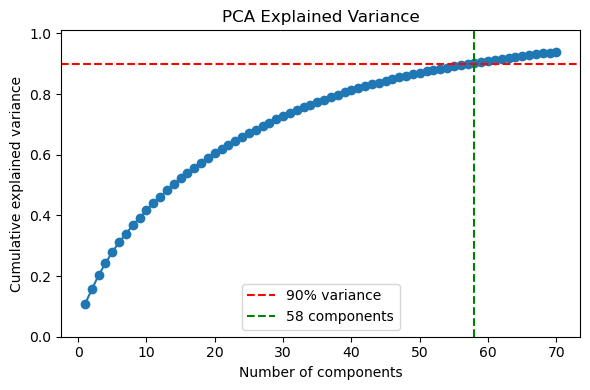

90% variance reached at 58 components.


In [17]:
def plot_explained_variance(rf_maps, max_components=30):
    """
    Plot cumulative explained variance of PCA on RF maps and mark 90% point.

    Parameters
    ----------
    rf_maps : array-like (N, H, W)
    max_components : int
        Max number of components to compute.
    standardize : {'none','per_neuron','per_pixel'}
        - 'none': raw flattened values
        - 'per_neuron': z-score each RF (row-wise)
        - 'per_pixel': z-score each pixel across neurons (column-wise)
    """
    rf_maps = np.array(rf_maps)
    N = rf_maps.shape[0]
    
    X_flat = rf_flatten_features(rf_maps, normalize=True)

    n_comp = min(max_components, X_flat.shape[1], N)
    pca = PCA(n_components=n_comp)
    pca.fit(X_flat)
    explained = np.cumsum(pca.explained_variance_ratio_)

    # where we cross 90%
    n90 = np.argmax(explained >= 0.9) + 1

    plt.figure(figsize=(6,4))
    plt.plot(np.arange(1, n_comp+1), explained, marker='o')
    plt.axhline(0.9, color='r', linestyle='--', label='90% variance')
    plt.axvline(n90, color='g', linestyle='--', label=f'{n90} components')
    plt.ylim(0, 1.01)  # force full 0-1 range so you can see the jump
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative explained variance')
    plt.title('PCA Explained Variance')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"90% variance reached at {n90} components.")


plot_explained_variance(rf_maps, max_components=70)

In [18]:
def reduce_features(X, n_components=25, scale=True):
    """
    Optional scaling + PCA reduction.
    Returns reduced feature matrix and fitted PCA object.
    """
    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X
    pca = PCA(n_components
)
    X_red = pca.fit_transform(X_scaled)
    return X_red, pca

In [19]:
from sklearn.manifold import TSNE
def tsne_analysis(X, rf_maps, roi_positions, perplexity=30, random_state=42):
    """
    Comprehensive t-SNE analysis for dimensionality reduction and visualization.
    """
    print("Running t-SNE analysis...")
    
    # 1. Standard t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity,
                random_state=random_state, verbose=1)
    X_tsne = tsne.fit_transform(X)

    return X_tsne

In [20]:
X_flat = rf_flatten_features(rf_maps)
# Run PCA
X_red_pca, pca = reduce_features(X_flat, n_components=58)
# Run t-SNE
tsne_results = tsne_analysis(X_red_pca, rf_maps, roi_positions)

Running t-SNE analysis...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 189 samples in 0.000s...
[t-SNE] Computed neighbors for 189 samples in 2.084s...
[t-SNE] Computed conditional probabilities for sample 189 / 189
[t-SNE] Mean sigma: 8.047093
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.404549
[t-SNE] KL divergence after 1000 iterations: 1.047104


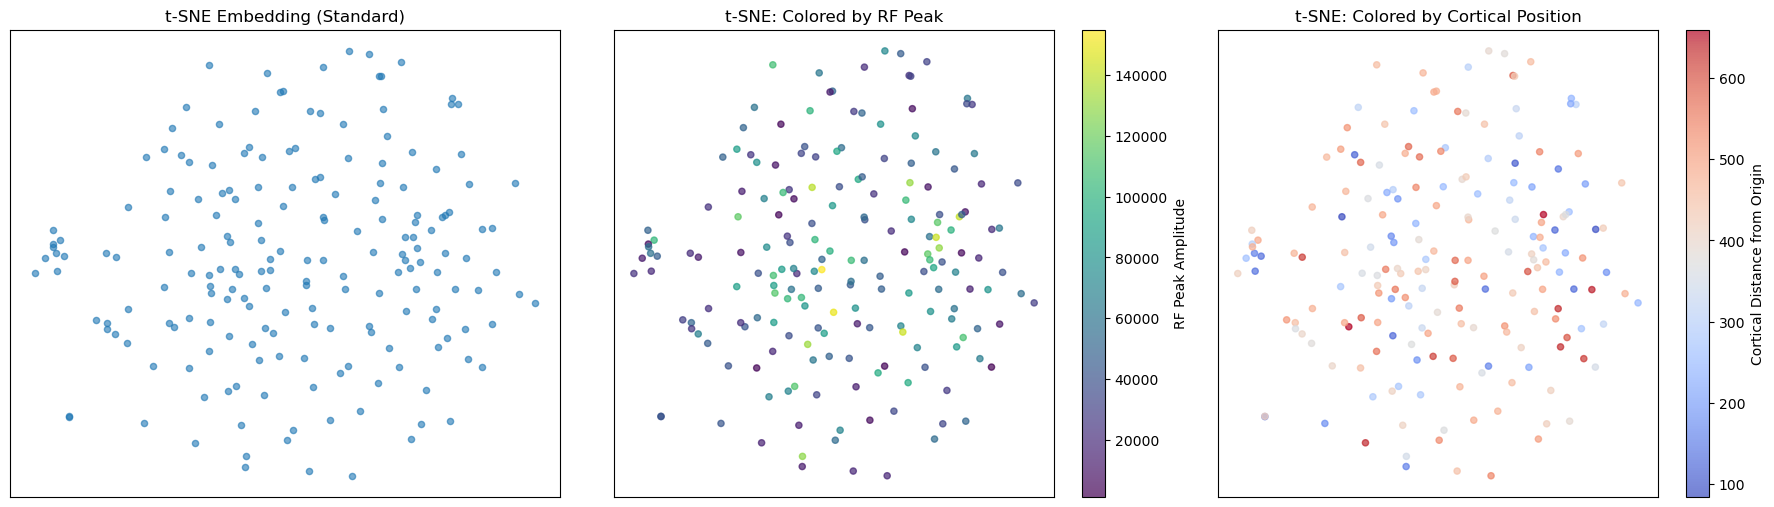

In [21]:
def plot_tsne_analysis(tsne_results, rf_maps, roi_positions, labels_dict=None):
    """
    Comprehensive t-SNE visualization.
    """
    
    # 1. Standard t-SNE plot
    plt.figure(figsize=(18, 10))
    
    # Main t-SNE plot
    plt.subplot(2, 3, 1)
    plt.scatter(tsne_results[:, 0], 
                tsne_results[:, 1], 
                alpha=0.6, s=20)
    plt.title('t-SNE Embedding (Standard)')
    plt.xticks([])
    plt.yticks([])

    
    # 2. t-SNE with RF peak amplitude coloring
    rf_peaks = [compute_rf_peak(rf) for rf in rf_maps]
    plt.subplot(2, 3, 2)
    scatter = plt.scatter(tsne_results[:, 0], 
                         tsne_results[:, 1], 
                         c=rf_peaks, cmap='viridis', alpha=0.7, s=20)
    plt.colorbar(scatter, label='RF Peak Amplitude')
    plt.title('t-SNE: Colored by RF Peak')
    plt.xticks([])
    plt.yticks([])
    
    
    # 6. Cortical position correlation
    plt.subplot(2, 3, 3)
    cortical_distances = np.sqrt(roi_positions[:, 0]**2 + roi_positions[:, 1]**2)
    scatter = plt.scatter(tsne_results[:, 0], 
                         tsne_results[:, 1], 
                         c=cortical_distances, cmap='coolwarm', alpha=0.7, s=20)
    plt.colorbar(scatter, label='Cortical Distance from Origin')
    plt.title('t-SNE: Colored by Cortical Position')
    plt.xticks([])
    plt.yticks([])
    
    plt.tight_layout()
    plt.show()
    
# Plot t-SNE analysis
plot_tsne_analysis(tsne_results, rf_maps, roi_positions)

The left panel displays the overall distribution of neurons in the t-SNE space, there is no clear groupings is visually apparent.

The middle panel colors neurons by RF peak amplitude, suggesting some local variation in response strength, though strong clustering by peak is not evident. 

The right panel shows cortical positions, with some spatial gradients, but no obvious anatomical separation is visible in the embedding. 

Overall, these plots suggest possible underlying structure, but no pronounced functional or anatomical clusters can be directly inferred from this visualization alone

###  Clustering Methodology

- **K-means**: Hard clustering with spherical clusters, computationally efficient
- **Gaussian Mixture Models (GMM)**: Soft clustering with elliptical clusters, probabilistic assignments
- **Model Selection**: Multi-criteria evaluation using statistical and biological scores.


#### Statistical Evaluation: 
- **Silhouette score**: Measures how similar each neuron is to its own cluster compared to other clusters. Higher values indicate better-defined and more separated clusters.
- **Davies-Bouldin score**: Assesses the average similarity between each cluster and its most similar other cluster. Lower values indicate better clustering with more distinct and compact clusters.

#### Biological Plausibility:
- **Spatial Coherence**: How similar RFs are within clusters
- **Distinctiveness**: How different cluster means are from each other
- **Spatial Organization**: Cortical clustering of functionally similar neurons
- **Symmetry Consistency**: Uniformity of RF symmetry within clusters


In [22]:
def cluster_on_tsne_embeddings(tsne_results, rf_maps, roi_positions, n_clusters_range=range(2, 11)):
    """
    Apply clustering methods to t-SNE embeddings with different numbers of clusters.
    
    Parameters:
    -----------
    tsne_results : array-like
        t-SNE embedding results
    rf_maps : array-like
        Receptive field maps
    roi_positions : array-like
        ROI positions
    n_clusters_range : range
        Range of cluster numbers to try (default: range(2, 11) for 2-10 clusters)
    
    Returns:
    --------
    results : dict
        Dictionary containing results for each method and cluster number
    """
    
    X_tsne = tsne_results
    results = {}
    
    # Try different numbers of clusters
    for n_clusters in n_clusters_range:
        print(f"Testing {n_clusters} clusters...")
        
        # 1. K-means on t-SNE
        kmeans_tsne = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        labels = kmeans_tsne.fit_predict(X_tsne)
        results[f'kmeans_tsne_k{n_clusters}'] = {
            'labels': labels, 'k': n_clusters,
            'silhouette': silhouette_score(X_tsne, labels),
            'davies_bouldin': davies_bouldin_score(X_tsne, labels),
        }
        
        # 2. GMM on t-SNE
        gmm_tsne = GaussianMixture(n_components=n_clusters, random_state=42)
        labels = gmm_tsne.fit_predict(X_tsne)
        results[f'gmm_tsne_k{n_clusters}'] = {
            'labels': labels, 'k': n_clusters,
            'silhouette': silhouette_score(X_tsne, labels),
            'davies_bouldin': davies_bouldin_score(X_tsne, labels),
        }
    
    return results


In [23]:
def enhanced_biological_plausibility_tests(rf_maps, labels, roi_positions):
    """
    Comprehensive biological plausibility assessment.
    """
    
    unique_labels = np.unique(labels[labels >= 0])
    if len(unique_labels) < 2:
        return {}
    
    results = {}
    
    # 1. Spatial coherence within clusters
    spatial_coherence = []
    for label in unique_labels:
        cluster_mask = labels == label
        cluster_rfs = rf_maps[cluster_mask]
        
        if len(cluster_rfs) < 2:
            continue
            
        # Compute mean RF for cluster
        cluster_mean = np.mean(cluster_rfs, axis=0)
        
        # Correlation of each RF with cluster mean
        correlations = []
        for rf in cluster_rfs:
            corr = np.corrcoef(rf.flatten(), cluster_mean.flatten())[0, 1]
            if not np.isnan(corr):
                correlations.append(corr)
        
        if correlations:
            spatial_coherence.append(np.mean(correlations))
    
    results['spatial_coherence'] = np.mean(spatial_coherence) if spatial_coherence else 0.0
    
    # 2. Cluster distinctiveness
    cluster_means = []
    for label in unique_labels:
        cluster_mask = labels == label
        if np.sum(cluster_mask) > 0:
            cluster_mean = np.mean(rf_maps[cluster_mask], axis=0)
            cluster_means.append(cluster_mean)
    
    if len(cluster_means) > 1:
        # Compute pairwise correlations between cluster means
        distinctiveness_scores = []
        for i in range(len(cluster_means)):
            for j in range(i+1, len(cluster_means)):
                corr = np.corrcoef(cluster_means[i].flatten(), cluster_means[j].flatten())[0, 1]
                if not np.isnan(corr):
                    distinctiveness_scores.append(1.0 - abs(corr))
        
        results['distinctiveness'] = np.mean(distinctiveness_scores) if distinctiveness_scores else 0.0
    else:
        results['distinctiveness'] = 0.0
    
    
    # 4. Spatial organization (cortical clustering)
    spatial_organization = []
    for label in unique_labels:
        cluster_mask = labels == label
        cluster_positions = roi_positions[cluster_mask]
        
        if len(cluster_positions) < 2:
            continue
            
        # Compute mean distance between cluster members
        from scipy.spatial.distance import pdist
        distances = pdist(cluster_positions)
        mean_distance = np.mean(distances)
        
        # Compare to random expectation
        random_distances = []
        for _ in range(100):
            random_indices = np.random.choice(len(roi_positions), len(cluster_positions), replace=False)
            random_positions = roi_positions[random_indices]
            random_dist = np.mean(pdist(random_positions))
            random_distances.append(random_dist)
        
        random_mean = np.mean(random_distances)
        if random_mean > 0:
            organization_score = 1.0 - (mean_distance / random_mean)
            spatial_organization.append(max(0.0, organization_score))
    
    results['spatial_organization'] = np.mean(spatial_organization) if spatial_organization else 0.0
    
    # 5. RF symmetry consistency
    symmetry_consistency = []
    for label in unique_labels:
        cluster_mask = labels == label
        cluster_rfs = rf_maps[cluster_mask]
        
        if len(cluster_rfs) < 2:
            continue
            
        symmetries = []
        for rf in cluster_rfs:
            sym = rf_symmetry(rf, axis=1)
            if not np.isnan(sym):
                symmetries.append(abs(sym))
        
        if symmetries:
            consistency = 1.0 - np.std(symmetries)
            symmetry_consistency.append(max(0.0, consistency))
    
    results['symmetry_consistency'] = np.mean(symmetry_consistency) if symmetry_consistency else 0.0
    
    # 6. Overall biological plausibility score
    weights = {
        'spatial_coherence': 0.25,
        'distinctiveness': 0.25,
        'spatial_organization': 0.20,
        'symmetry_consistency': 0.15
    }
    
    total_score = sum(weights[criterion] * results[criterion] for criterion in weights.keys())
    results['overall_plausibility'] = total_score
    
    return results

In [24]:
def comprehensive_method_comparison(tsne_results, rf_maps, roi_positions, n_clusters_range=range(2, 11)):
    """
    Compare all clustering methods comprehensively with different cluster numbers.
    
    Parameters:
    -----------
    X_red : array-like
        Reduced feature matrix
    rf_maps : array-like
        Receptive field maps
    roi_positions : array-like
        ROI positions
    tsne_results : array-like
        t-SNE embedding results
    n_clusters_range : range
        Range of cluster numbers to try (default: range(2, 11) for 2-10 clusters)
    
    Returns:
    --------
    comparison_df : pandas.DataFrame
        Comparison results sorted by overall score
    all_results : dict
        All clustering results
    bio_scores : dict
        Biological plausibility scores
    """
    
    print("Running comprehensive method comparison...")
    
    # 1. Run all  methods with different cluster numbers
    advanced_results = cluster_on_tsne_embeddings(tsne_results, rf_maps, roi_positions, n_clusters_range)
    
    # 2. Combine all results
    all_results = {**advanced_results}
    
    # 3. Evaluate biological plausibility for all methods
    print("Evaluating biological plausibility...")
    bio_scores = {}
    for method_name, result in all_results.items():
        if result['labels'] is not None:
            bio_score = enhanced_biological_plausibility_tests(rf_maps, result['labels'], roi_positions)
            bio_scores[method_name] = bio_score
    
    # 4. Create comprehensive comparison table
    comparison_data = []
    for method_name, result in all_results.items():
        if result['labels'] is not None:
            bio_score = bio_scores.get(method_name, {})
            row = {
                'Method': method_name,
                'K': result['k'],
                'Silhouette': result['silhouette'],
                'Davies-Bouldin': result['davies_bouldin'],
                'Overall_Plausibility': bio_score.get('overall_plausibility', 0.0),
            }
            comparison_data.append(row)
    
    # 5. Create comparison DataFrame
    comparison_df = pd.DataFrame(comparison_data)
    
    # 6. Sort by overall score (weighted combination)
    comparison_df['Overall_Score'] = (
        0.3 * comparison_df['Silhouette'] + 
        0.2 * (1.0 / (1.0 + comparison_df['Davies-Bouldin'])) +
        0.3 * comparison_df['Overall_Plausibility']
    )
    
    comparison_df = comparison_df.sort_values('Overall_Score', ascending=False)
    
    return comparison_df, all_results, bio_scores

In [25]:
comparison_df, all_clustering_results, bio_scores = comprehensive_method_comparison(
    tsne_results, rf_maps, roi_positions, n_clusters_range=range(2, 11)
)


Running comprehensive method comparison...
Testing 2 clusters...
Testing 3 clusters...
Testing 4 clusters...
Testing 5 clusters...
Testing 6 clusters...
Testing 7 clusters...


c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

Testing 8 clusters...
Testing 9 clusters...
Testing 10 clusters...
Evaluating biological plausibility...


c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\aagne\anaconda3\envs\final_nds\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

In [26]:
def select_and_visualize_best_method(comparison_df, all_results, rf_maps, roi_positions, tsne_results):
    """
    Select the best method and create comprehensive visualizations.
    """
    
    # Get best method
    best_method = comparison_df.iloc[0]['Method']
    best_result = all_results[best_method]
    best_labels = best_result['labels']
    
    print(f"\n=== BEST METHOD: {best_method.upper()} ===")

    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(25, 12))
    
    # 1. t-SNE with best clustering
    plt.subplot(2, 4, 1)
    scatter = plt.scatter(tsne_results[:, 0], 
                         tsne_results[:, 1], 
                         c=best_labels, cmap='tab20', alpha=0.7, s=30)
    plt.title(f'{best_method.upper()}\nClusters in t-SNE Space')
    plt.colorbar(scatter, label='Cluster')
    
    # 2. Cortical space clustering
    plt.subplot(2, 4, 2)
    scatter = plt.scatter(roi_positions[:, 0], roi_positions[:, 1], 
                         c=best_labels, cmap='tab20', s=35, edgecolor='k', linewidth=0.3)
    plt.title(f'{best_method.upper()}\nClusters in Cortical Space')
    plt.xlabel('Cortical X')
    plt.ylabel('Cortical Y')
    plt.colorbar(scatter, label='Cluster')
    plt.gca().invert_yaxis()
    
    # 3. Cluster sizes
    plt.subplot(2, 4, 3)
    unique_labels, counts = np.unique(best_labels, return_counts=True)
    plt.bar(unique_labels, counts, color=plt.cm.tab20(unique_labels))
    plt.title('Cluster Sizes')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Neurons')
    
    # 4. RF properties by cluster
    plt.subplot(2, 4, 4)
    rf_peaks = [compute_rf_peak(rf) for rf in rf_maps]
    cluster_peaks = []
    for label in unique_labels:
        cluster_mask = best_labels == label
        cluster_peaks.append(np.mean([rf_peaks[i] for i in np.where(cluster_mask)[0]]))
    plt.bar(unique_labels, cluster_peaks, color=plt.cm.tab20(unique_labels))
    plt.title('Average RF Peak by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('RF Peak Amplitude')

    
    return best_method, best_labels

In [27]:
def select_and_visualize_best_method(comparison_df, all_results, rf_maps, roi_positions, tsne_results):
    """
    Select the best method and create comprehensive visualizations.
    """
    
    # Get best method
    best_method = comparison_df.iloc[0]['Method']
    best_result = all_results[best_method]
    best_labels = best_result['labels']
    
    print(f"\n=== BEST METHOD: {best_method.upper()} ===")

    # Define consistent colormap
    unique_labels = np.unique(best_labels)
    num_clusters = len(unique_labels)
    color_map = plt.cm.get_cmap('tab20', num_clusters)
    label_to_color = {label: color_map(i) for i, label in enumerate(unique_labels)}
    cluster_colors = np.array([label_to_color[label] for label in best_labels])

    # Create comprehensive visualization
    fig = plt.figure(figsize=(25, 12))

    # 1. t-SNE with best clustering
    plt.subplot(2, 4, 1)
    scatter = plt.scatter(tsne_results[:, 0], 
                          tsne_results[:, 1], 
                          c=cluster_colors, alpha=0.7, s=30)
    plt.title(f'{best_method.upper()}\nClusters in t-SNE Space')
    plt.xticks([])
    plt.yticks([])


    # 2. Cortical space clustering
    plt.subplot(2, 4, 2)
    scatter = plt.scatter(roi_positions[:, 0], roi_positions[:, 1], 
                          c=cluster_colors, s=35, edgecolor='k', linewidth=0.3)
    plt.title(f'{best_method.upper()}\nClusters in Cortical Space')
    plt.xlabel('Cortical X')
    plt.ylabel('Cortical Y')

    plt.gca().invert_yaxis()

    # 3. Cluster sizes
    plt.subplot(2, 4, 3)
    counts = [np.sum(best_labels == label) for label in unique_labels]
    bar_colors = [label_to_color[label] for label in unique_labels]
    plt.bar(unique_labels, counts, color=bar_colors)
    plt.title('Cluster Sizes')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Neurons')

    # 4. RF properties by cluster
    plt.subplot(2, 4, 4)
    rf_peaks = [compute_rf_peak(rf) for rf in rf_maps]
    cluster_peaks = []
    for label in unique_labels:
        cluster_mask = best_labels == label
        cluster_peaks.append(np.mean([rf_peaks[i] for i in np.where(cluster_mask)[0]]))
    plt.bar(unique_labels, cluster_peaks, color=bar_colors)
    plt.title('Average RF Peak by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('RF Peak Amplitude')

    return best_method, best_labels


In [28]:
def cluster_average_rfs(rf_maps, labels, zscore_each=True):
    """
    Returns dict: cluster_label -> average RF map.
    Optionally z-score each RF before averaging to equalize amplitude.
    """
    rf_maps = np.asarray(rf_maps)
    unique_labels = np.unique(labels)
    cluster_means = {}
    for lab in unique_labels:
        idx = np.where(labels == lab)[0]
        if len(idx) == 0 or lab < 0:
            continue
        subset = rf_maps[idx]
        if zscore_each:
            # z-score each map across pixels
            s = subset.reshape(len(idx), -1)
            s = (s - s.mean(axis=1, keepdims=True)) / (s.std(axis=1, keepdims=True) + 1e-8)
            subset = s.reshape(subset.shape)
        cluster_means[lab] = subset.mean(axis=0)
    return cluster_means

import matplotlib.gridspec as gridspec

def plot_cluster_average_rfs(cluster_means, n_cols=5, cmap='bwr'):
    keys = sorted(cluster_means.keys())
    n = len(keys)
    n_cols = min(n_cols, n)
    n_rows = int(np.ceil(n / n_cols))

    v = max(np.max(np.abs(m)) for m in cluster_means.values())

    # Create figure and GridSpec
    fig = plt.figure(figsize=(3 * n_cols + 2, 3 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols + 1, width_ratios=[1]*n_cols + [0.05], wspace=0.3)

    im = None  # Reference for colorbar
    for idx, lab in enumerate(keys):
        row, col = divmod(idx, n_cols)
        ax = fig.add_subplot(gs[row, col])
        im = ax.imshow(cluster_means[lab], cmap=cmap, vmin=-v, vmax=v, interpolation='nearest')
        ax.set_title(f'Cluster {lab}', fontsize=7)
        ax.axis('off')

    # Add shared colorbar in the last column
    cax = fig.add_subplot(gs[:, -1])
    fig.colorbar(im, cax=cax, label='RF Intensity')

    fig.suptitle("Cluster Average Receptive Field", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.8, 0.8])  # Leave room for suptitle
    plt.show()



=== BEST METHOD: GMM_TSNE_K5 ===


C:\Users\aagne\AppData\Local\Temp\ipykernel_43812\356654228.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_clusters)
C:\Users\aagne\AppData\Local\Temp\ipykernel_43812\4056863732.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.8, 0.8])  # Leave room for suptitle


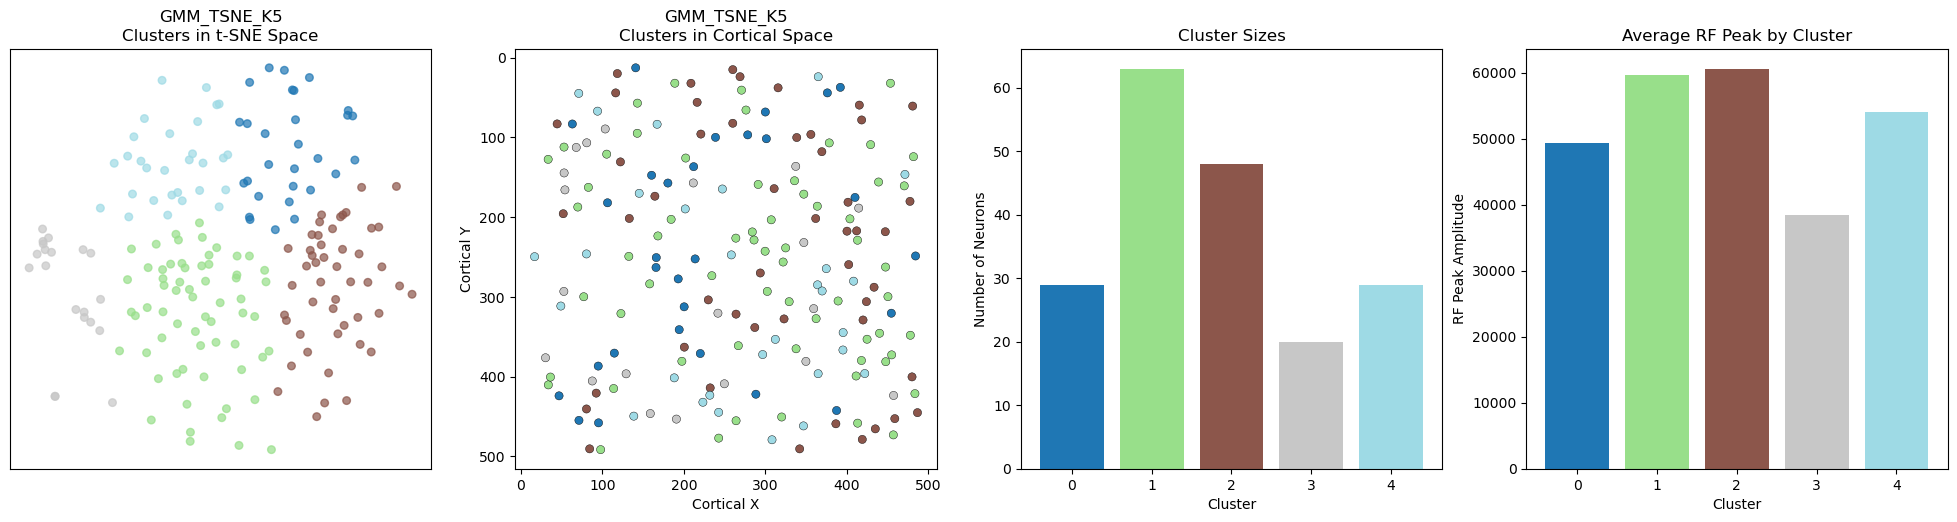

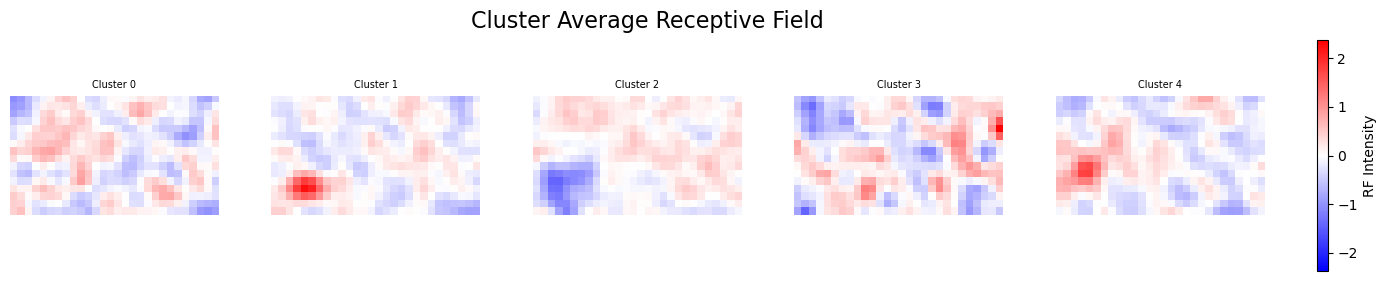

In [29]:
# Select and visualize the best method (which now includes optimal cluster number)
best_method, best_labels = select_and_visualize_best_method(
    comparison_df, all_clustering_results, rf_maps, roi_positions, tsne_results
)

# Plot cluster averages for the best method
cluster_means = cluster_average_rfs(rf_maps, best_labels)
plot_cluster_average_rfs(cluster_means)

In t-SNE space, the clusters identified by the GMM algorithm appear well separated, indicating that the receptive field features allow for clear functional grouping. However, when mapped onto cortical space, the anatomical separation is less pronounced—some clusters are spatially intermixed, and there is no strong evidence for neat anatomical clustering.

Cluster sizes are balanced, with no single cluster dominating the population. The average RF peak amplitude varies across clusters, reflecting differences in response strength.

Based on the average receptive fields and their spatial patterns, we can speculate on the functional roles of each cluster:

- **Clusters 1 and 2:** These show strong, localized "on-off" patterns in their average RFs, suggesting they are highly sensitive to specific regions of the stimulus. Neurons in these clusters likely act as feature detectors, responding robustly to distinct spatial inputs and contributing to precise sensory encoding.

- **Cluster 4:** This cluster also displays a pronounced "on" response, indicating a preference for activation by specific stimulus regions. Its neurons may serve a similar role to clusters 1 and 2, but with a bias toward excitatory responses.

- **Clusters 0 and 3:** These clusters do not exhibit localized activity in their average RFs. Instead, their receptive fields are more diffuse, which may reflect roles in integrating information over broader spatial areas or modulating the activity of other neurons. Cluster 0 could be involved in background integration or gain control, while cluster 3 might contribute to contextual modulation or global inhibition.

Overall, the diversity in RF patterns across clusters suggests a division of labor, with some neurons specialized for detecting specific features and others supporting integration and modulation within the network.